<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/Week2Day3_Murcko_scaffold_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 47.5 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdFingerprintGenerator, AllChem, DataStructs
import pandas as pd
import numpy as np
from rdkit.Chem import MolStandardize
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Cluster import Butina
from rdkit import DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df_clean = pd.read_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv')
print(df_clean.shape)

Mounted at /content/drive
(3477, 14)


In [ ]:
#Compute scaffolds for every compound.
#The standard Murcko scaffold keeps atom identity, the generic framework flattens everything to carbon
def get_scaffold(smiles, generic=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if generic:
        scaffold = MurckoScaffold.MakeScaffoldGeneric(scaffold)
    return Chem.MolToSmiles(scaffold)

df_clean['scaffold'] = df_clean['canonical_smiles_std'].apply(lambda s: get_scaffold(s, generic=False))
df_clean['scaffold_generic'] = df_clean['canonical_smiles_std'].apply(lambda s: get_scaffold(s, generic=True))

print(f"Unique Murcko scaffolds: {df_clean['scaffold'].nunique()}")
print(f"Unique generic frameworks: {df_clean['scaffold_generic'].nunique()}")

Unique Murcko scaffolds: 1434
Unique generic frameworks: 854


In [ ]:
#Scaffold frequency
scaffold_counts = df_clean['scaffold'].value_counts()
print(f"Total unique scaffolds: {len(scaffold_counts)}")
print(f"Scaffolds appearing only once (singletons): {(scaffold_counts == 1).sum()}")
print(f"\nTop 10 scaffolds by frequency:")
print(scaffold_counts.head(10))

Total unique scaffolds: 1434
Scaffolds appearing only once (singletons): 990

Top 10 scaffolds by frequency:
scaffold
c1ccc(Oc2cccc(Oc3ccccc3)n2)cc1                            89
O=C(Nc1ccc(-c2ccccc2)cc1)c1ccnn1-c1ccccc1                 58
O=C(NCC1CCN(c2ccncc2)CC1)c1cccc(OCCc2ccccc2)c1            53
O=C(Nc1ccc(-c2ccccc2)cc1)C1CC(c2ccccc2)=NO1               50
O=C(C(Cc1ccccc1)NS(=O)(=O)c1ccccc1)N1CCCCC1               46
O=C(C(Cc1ccccc1)NS(=O)(=O)c1cccc(-c2ccccc2)c1)N1CCCCC1    45
O=C(NCc1ccccc1)c1cc2ccccc2n1Cc1ccccc1                     45
O=C1c2c(cnn2-c2ccccc2)CCN1c1ccc(C2CC2)cc1                 41
O=C(Nc1ccccc1C(=O)Nc1ccccc1)c1cc2ccccc2s1                 37
O=C(NC1CCNCC1)c1cc2ccccc2n1Cc1cc(-c2cccs2)on1             37
Name: count, dtype: int64


In [ ]:
# scaffold diversity number
n_compounds = len(df_clean)
n_scaffolds = df_clean['scaffold'].nunique()
print(f"Scaffold diversity ratio: {n_scaffolds / n_compounds:.3f}")
print(f"({n_scaffolds} scaffolds / {n_compounds} compounds)")

Scaffold diversity ratio: 0.412
(1434 scaffolds / 3477 compounds)


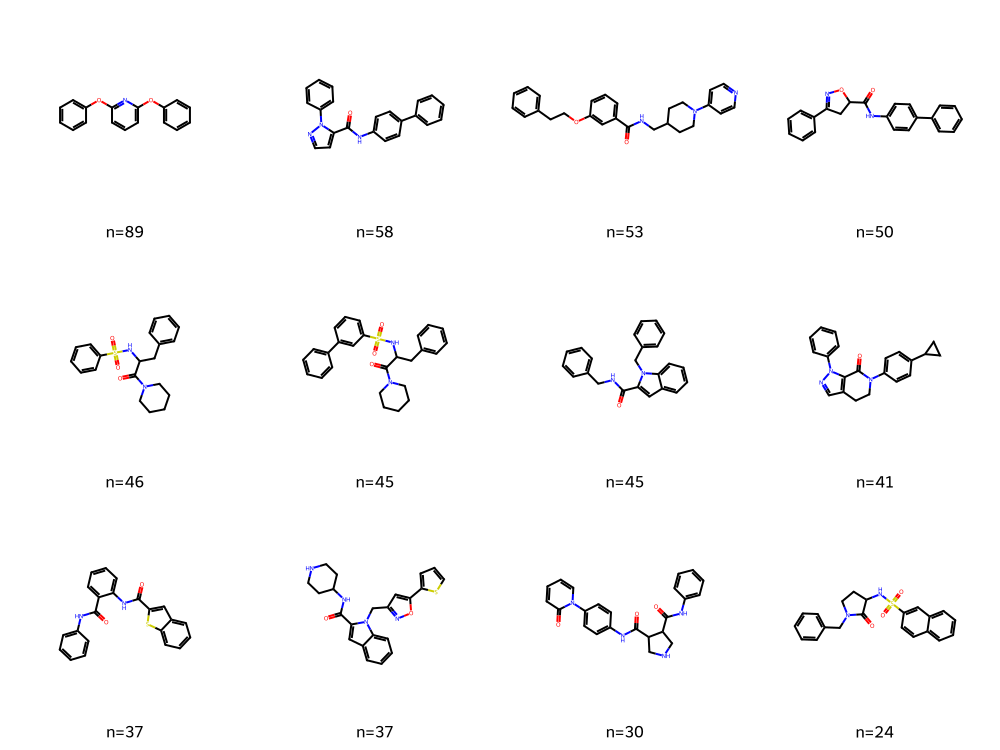

In [ ]:
top_scaffolds = scaffold_counts.head(12).index.tolist()
scaffold_mols = [Chem.MolFromSmiles(s) for s in top_scaffolds]

img = Draw.MolsToGridImage(
    scaffold_mols, molsPerRow=4, subImgSize=(250, 250),
    legends=[f"n={scaffold_counts[s]}" for s in top_scaffolds]
)
img

In [ ]:
# Linking scaffolds to potency
scaffold_potency = df_clean.groupby('scaffold').agg(
    count=('pKi', 'size'),
    mean_pKi=('pKi', 'mean'),
    max_pKi=('pKi', 'max')
).reset_index()

# only scaffolds with enough compounds to be meaningful
well_populated = scaffold_potency[scaffold_potency['count'] >= 5]
well_populated = well_populated.sort_values('mean_pKi', ascending=False)

print("Most potent scaffolds (>=5 compounds), by mean pKi:")
print(well_populated.head(10).to_string(index=False))

Most potent scaffolds (>=5 compounds), by mean pKi:
                                                  scaffold  count  mean_pKi   max_pKi
             O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1cc(Cn2ccnc2)cs1      6 11.007820 11.301030
  O=C1C(NS(=O)(=O)c2cc3cccnc3s2)CCCN1c1ccc(-n2ccccc2=O)cc1      7 10.367206 10.886057
           O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1cc(CNC2=NCCO2)cs1      7 10.095514 11.154902
                       O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1cccs1     17  9.811025 10.698970
        O=C1c2c(cnn2-c2ccc3oncc3c2)CCN1c1ccc(-c2ccccc2)cc1      5  9.794152 10.397940
O=C1c2c(cnn2-c2ccc3oncc3c2)CCN1c1ccc(-c2ccccc2CN2CCCC2)cc1      8  9.778634 10.522879
            O=C(Nc1ccc(-n2cnc3ccccc32)cc1)c1ccnn1-c1ccccc1     10  9.713739 10.096910
          O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1ccc(N2CCCCC2=O)cc1      9  9.642477 10.327902
                 c1ccc2cc(Cn3cnc4ccc(OC5CCNCC5)cc43)ccc2c1     10  9.617241 10.585027
           O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1ccc(-c2ccccc2)cc1      9  9.569053 10.000000


Most potent series: mean pKi 11.01 across 6 compounds


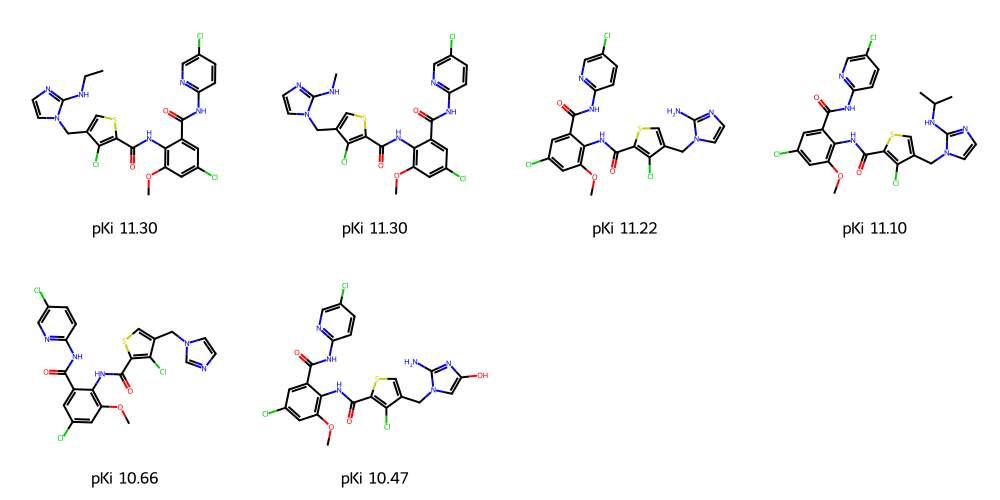

In [ ]:
#Most potent well populated scaffold
best_scaffold = well_populated.iloc[0]['scaffold']
print(f"Most potent series: mean pKi {well_populated.iloc[0]['mean_pKi']:.2f} "
      f"across {int(well_populated.iloc[0]['count'])} compounds")

# show example compounds bearing this scaffold
members = df_clean[df_clean['scaffold'] == best_scaffold].nlargest(8, 'pKi')
member_mols = [Chem.MolFromSmiles(s) for s in members['canonical_smiles_std']]
img = Draw.MolsToGridImage(
    member_mols, molsPerRow=4, subImgSize=(250, 250),
    legends=[f"pKi {p:.2f}" for p in members['pKi']]
)
img

In [ ]:
df_clean.to_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv', index=False)